In [1]:
from __future__ import annotations
 
import sys
from datetime import datetime, timezone
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import pandas as pd
BASE_DIR = Path("../data/raw")

datasets = {
    "videos": [],
    "comments": [],
    "channels": [],
}

for csv_file in BASE_DIR.rglob("*.csv"):
    try:
        df = pd.read_csv(csv_file)

        df["source_file"] = csv_file.name
        df["source_path"] = str(csv_file)

        id_dir = next(
            (part for part in csv_file.parts if part.startswith("id_")),
            None
        )
        df["collection_id"] = id_dir

        stem_parts = csv_file.stem.split("_")
        country = stem_parts[-1] if len(stem_parts) > 2 else None
        df["country"] = country

        filename = csv_file.name.lower()

        if "video" in filename:
            datasets["videos"].append(df)

        elif "comment" in filename:
            datasets["comments"].append(df)

        elif "channel" in filename:
            datasets["channels"].append(df)

    except Exception as e:
        print(f"Erro ao ler {csv_file}: {e}")

videos_df = pd.concat(datasets["videos"], ignore_index=True) \
    if datasets["videos"] else pd.DataFrame()

comments_df = pd.concat(datasets["comments"], ignore_index=True) \
    if datasets["comments"] else pd.DataFrame()

channels_df = pd.concat(datasets["channels"], ignore_index=True) \
    if datasets["channels"] else pd.DataFrame()

print(f"Videos: {len(videos_df)}")
print(f"Comments: {len(comments_df)}")
print(f"Channels: {len(channels_df)}")


Videos: 3983
Comments: 226196
Channels: 3970


In [2]:
from IPython.display import display, Markdown
display(Markdown("## visão geral e estrutura do dataset"))
videos_df.info() 

display(Markdown("---"))

display(Markdown("## amostra dos dados (primeiras 5 linhas)"))
display(videos_df.head())

display(Markdown("---"))

display(Markdown("##  rsumo estatístico (variáveis nméricas)"))
display(videos_df.describe()) 

if videos_df.select_dtypes(include=['object']).shape[1] > 0:
    display(Markdown("## resumo estatístico (variáveis categóricas)"))
    display(videos_df.describe())

## visão geral e estrutura do dataset

<class 'pandas.DataFrame'>
RangeIndex: 3983 entries, 0 to 3982
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   video_id       3983 non-null   str    
 1   title          3983 non-null   str    
 2   channel_title  3983 non-null   str    
 3   channel_id     3983 non-null   str    
 4   published_at   3983 non-null   str    
 5   category_id    3983 non-null   int64  
 6   thumbnail      3983 non-null   str    
 7   view_count     3983 non-null   int64  
 8   like_count     3882 non-null   float64
 9   comment_count  3973 non-null   float64
 10  source_file    3983 non-null   str    
 11  source_path    3983 non-null   str    
 12  collection_id  3983 non-null   str    
 13  country        3983 non-null   str    
dtypes: float64(2), int64(2), str(10)
memory usage: 1.4 MB


---

## amostra dos dados (primeiras 5 linhas)

,video_id,title,channel_title,channel_id,published_at,category_id,thumbnail,view_count,like_count,comment_count,source_file,source_path,collection_id,country
0,Vagb9BqdX8g,We Almost Lost EVERYTHING Gambling,SMii7Yplus,UC-gW4TeZAlKm7UATp24JsWQ,2026-05-31T19:13:22Z,20,https://i.ytimg.com/vi/Vagb9BqdX8g/default.jpg,1016152,52805.0,1511.0,youtube_videos_us.csv,../data/raw/output_default_093801062026/id_20/...,id_20,us
1,NtFNQEry2X0,PLAYING HARDCORE MINECRAFT UNTIL WE BEAT IT,Jynxzi,UCjiXtODGCCulmhwypZAWSag,2026-06-01T06:21:44Z,24,https://i.ytimg.com/vi/NtFNQEry2X0/default.jpg,1243305,16786.0,105.0,youtube_videos_us.csv,../data/raw/output_default_093801062026/id_20/...,id_20,us
2,UnFIrVKA9Zc,1000 VS 1000 Player Minecraft Civil War,FlameFrags,UCvYPobTo42NM36X7VC4dLhA,2026-06-01T04:10:04Z,20,https://i.ytimg.com/vi/UnFIrVKA9Zc/default.jpg,896961,79268.0,19726.0,youtube_videos_us.csv,../data/raw/output_default_093801062026/id_20/...,id_20,us
3,OlQEoEPMJUo,"Hydroneer Tried to Optimize, So I Double Overl...",Let's Game It Out,UCto7D1L-MiRoOziCXK9uT5Q,2026-05-31T14:49:03Z,20,https://i.ytimg.com/vi/OlQEoEPMJUo/default.jpg,1255432,72728.0,3050.0,youtube_videos_us.csv,../data/raw/output_default_093801062026/id_20/...,id_20,us
4,A8ZfNutzOTM,The Wheel of MLB the Show!,MMG,UCaYxyR9mzVlTrOOyZD0XAmA,2026-05-31T22:00:26Z,17,https://i.ytimg.com/vi/A8ZfNutzOTM/default.jpg,170738,12163.0,1521.0,youtube_videos_us.csv,../data/raw/output_default_093801062026/id_20/...,id_20,us


...

##  rsumo estatístico (variáveis nméricas)

,category_id,view_count,like_count,comment_count
count,3983.000000,3.983000e+03,3.882000e+03,3973.000000
mean,21.065026,2.350681e+06,8.416439e+04,1180.882205
std,5.030898,7.340565e+06,1.813868e+05,4634.421490
min,1.000000,3.529000e+03,1.210000e+02,0.000000
25%,20.000000,1.911665e+05,7.704750e+03,147.000000
50%,22.000000,7.650620e+05,2.818000e+04,409.000000
75%,24.000000,2.232216e+06,8.379400e+04,1054.000000
max,29.000000,1.565006e+08,2.635306e+06,154500.000000


/tmp/ipykernel_58702/685646150.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  if videos_df.select_dtypes(include=['object']).shape[1] > 0:


## resumo estatístico (variáveis categóricas)

,category_id,view_count,like_count,comment_count
count,3983.000000,3.983000e+03,3.882000e+03,3973.000000
mean,21.065026,2.350681e+06,8.416439e+04,1180.882205
std,5.030898,7.340565e+06,1.813868e+05,4634.421490
min,1.000000,3.529000e+03,1.210000e+02,0.000000
25%,20.000000,1.911665e+05,7.704750e+03,147.000000
50%,22.000000,7.650620e+05,2.818000e+04,409.000000
75%,24.000000,2.232216e+06,8.379400e+04,1054.000000
max,29.000000,1.565006e+08,2.635306e+06,154500.000000


In [3]:
null_pct = df.isnull().mean().sort_values(ascending=False)
null_abs = df.isnull().sum().sort_values(ascending=False)
null_df = pd.DataFrame({"nulos": null_abs, "pct_%": (null_pct*100).round(1)})
display(null_df.to_string())


'                         nulos  pct_%\ndescription                 10    8.3\nchannel_id                   0    0.0\ntitle                        0    0.0\ncustom_url                   0    0.0\npublished_at                 0    0.0\ncountry                      0    0.0\nthumbnail                    0    0.0\nview_count                   0    0.0\nsubscriber_count             0    0.0\nvideo_count                  0    0.0\nhidden_subscriber_count      0    0.0\nsource_file                  0    0.0\nsource_path                  0    0.0\ncollection_id                0    0.0'

In [4]:
import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from datetime import datetime

In [5]:
# display(Markdown("## LIMPEZA DE DADOS\n"))
 
# df_clean = videos_df.copy()

# df_clean = df_clean.replace(["", "None", "nan", "NaN", "unknown"], np.nan)

# cols_100_null = ["thumbnail", "channel_title"]
# df_clean.drop(columns=cols_100_null, inplace=True)
# display(Markdown(f"Removidas {len(cols_100_null)} colunas 100% nulas: {cols_100_null}"))

# df_clean = df_clean[df_clean['country'] != 'channel']

# dup_count = df_clean.duplicated(subset="video_id").sum()
# df_clean.drop_duplicates(subset="video_id", inplace=True)
# display(Markdown(f"Duplicatas removidas por video_id: {dup_count}"))
 
# df_clean["published_at"] = pd.to_datetime(df_clean["published_at"], errors="coerce")
# display(Markdown(f"published_at convertido para datetime"))
 
# LIKE_WEIGHT = 2
# COMMENT_WEIGHT = 5
# num_cols = ["view_count", "like_count", "comment_count", "official_category_id", "category_id"]
# for col in num_cols:
#     if col in df_clean.columns:
#         df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")
        
# df_clean["engagement_rate"] = np.where(
#     df_clean["view_count"] > 0,
#     (
#         df_clean["like_count"].fillna(0) * LIKE_WEIGHT +
#         df_clean["comment_count"].fillna(0) * COMMENT_WEIGHT
#     ) / df_clean["view_count"],
#     np.nan
# )
# df_clean["like_ratio"]    = df_clean["like_count"]    / df_clean["view_count"]
# df_clean["comment_ratio"] = df_clean["comment_count"] / df_clean["view_count"]
# display(Markdown(f"Criadas colunas: engagement_rate, like_ratio, comment_ratio"))
 
# df_clean["year"]  = df_clean["published_at"].dt.year
# df_clean["month"] = df_clean["published_at"].dt.month
# display(Markdown(f"Criadas colunas: year, month"))
 
# cap_views = df_clean["view_count"].quantile(0.995)
# outliers_n = (df_clean["view_count"] > cap_views).sum()
# df_clean["view_count_capped"] = df_clean["view_count"].clip(upper=cap_views)
# display(Markdown(f"view_count: {outliers_n} outliers capados no p99.5 ({cap_views:,.0f})"))
 
# # df_clean["source_label"] = df_clean["source_file"].str.replace(".csv","",regex=False)
# # display(Markdown(f"source_label criado"))
# display(Markdown(f"\nshape final: {df_clean.shape[0]} linhas x {df_clean.shape[1]} colunas"))

# POS_BASE_DIR = Path("../data/processed")
# POS_BASE_DIR.mkdir(parents=True, exist_ok=True)

# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
# file_name = f"processed_videos_{timestamp}.csv"
# caminho_final = POS_BASE_DIR / file_name

# df_clean.to_csv(caminho_final, index=False, sep=',', encoding='utf-8')

# display(Markdown(f"\nsalvo no caminho: {caminho_final}"))



In [6]:
df_clean = videos_df.copy()

df_clean = df_clean.replace(["", "None", "nan", "NaN", "unknown"], np.nan)

df_clean = df_clean[df_clean["country"] != "channel"]
df_clean = df_clean.drop_duplicates(subset="video_id")

df_clean = df_clean.drop(columns=["thumbnail", "channel_title"], errors="ignore")

df_clean["published_at"] = pd.to_datetime(df_clean["published_at"], errors="coerce")

num_cols = ["view_count", "like_count", "comment_count", "official_category_id", "category_id"]
for col in num_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

LIKE_WEIGHT = 2
COMMENT_WEIGHT = 5

valid_views = df_clean["view_count"].gt(0)

df_clean["engagement_rate"] = np.where(
    valid_views,
    (
        df_clean["like_count"].fillna(0) * LIKE_WEIGHT +
        df_clean["comment_count"].fillna(0) * COMMENT_WEIGHT
    ) / df_clean["view_count"],
    np.nan
)

df_clean["like_ratio"] = np.where(
    valid_views,
    df_clean["like_count"].fillna(0) / df_clean["view_count"],
    np.nan
)

df_clean["comment_ratio"] = np.where(
    valid_views,
    df_clean["comment_count"].fillna(0) / df_clean["view_count"],
    np.nan
)

df_clean["year"] = df_clean["published_at"].dt.year
df_clean["month"] = df_clean["published_at"].dt.month
df_clean["source_label"] = df_clean["source_file"].str.replace(".csv","",regex=False)

# cap_views = df_clean["view_count"].quantile(0.995)
cap_views = df_clean["view_count"].quantile(0.99)
df_clean["view_count_capped"] = df_clean["view_count"].clip(upper=cap_views)


imputer = SimpleImputer(strategy="median")

df_clean[["view_count", "like_count", "comment_count"]] = (
    imputer.fit_transform(
        df_clean[["view_count", "like_count", "comment_count"]]
    )
)

In [7]:
display(Markdown(f"\nshape final: {df_clean.shape[0]} linhas x {df_clean.shape[1]} colunas"))

POS_BASE_DIR = Path("../data/processed")
POS_BASE_DIR.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
file_name = f"processed_videos_{timestamp}.csv"
caminho_final = POS_BASE_DIR / file_name

df_clean.to_csv(caminho_final, index=False, sep=',', encoding='utf-8')

display(Markdown(f"\nsalvo no caminho: {caminho_final}"))


shape final: 2072 linhas x 19 colunas


salvo no caminho: ../data/processed/processed_videos_20260601_163134.csv

In [8]:
display(Markdown("## visão geral e estrutura do dataset"))
df_clean.info() 

display(Markdown("---"))

display(Markdown("## amostra dos dados (primeiras 5 linhas)"))
display(df_clean.head())

display(Markdown("---"))

display(Markdown("##  rsumo estatístico (variáveis nméricas)"))
display(df_clean.describe()) 

if df_clean.select_dtypes(include=['object']).shape[1] > 0:
    display(Markdown("## resumo estatístico (variáveis categóricas)"))
    display(df_clean.describe())

display(Markdown("##  colunas e etc"))
display(df_clean.columns)

## visão geral e estrutura do dataset

<class 'pandas.DataFrame'>
Index: 2072 entries, 0 to 3982
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   video_id           2072 non-null   str                
 1   title              2072 non-null   str                
 2   channel_id         2072 non-null   str                
 3   published_at       2072 non-null   datetime64[us, UTC]
 4   category_id        2072 non-null   int64              
 5   view_count         2072 non-null   float64            
 6   like_count         2072 non-null   float64            
 7   comment_count      2072 non-null   float64            
 8   source_file        2072 non-null   str                
 9   source_path        2072 non-null   str                
 10  collection_id      2072 non-null   str                
 11  country            2072 non-null   str                
 12  engagement_rate    2072 non-null   float64            
 13  like

---

## amostra dos dados (primeiras 5 linhas)

,video_id,title,channel_id,published_at,category_id,view_count,like_count,comment_count,source_file,source_path,collection_id,country,engagement_rate,like_ratio,comment_ratio,year,month,source_label,view_count_capped
0,Vagb9BqdX8g,We Almost Lost EVERYTHING Gambling,UC-gW4TeZAlKm7UATp24JsWQ,2026-05-31 19:13:22+00:00,20,1016152.0,52805.0,1511.0,youtube_videos_us.csv,../data/raw/output_default_093801062026/id_20/...,id_20,us,0.111366,0.051966,0.001487,2026,5,youtube_videos_us,1016152.0
1,NtFNQEry2X0,PLAYING HARDCORE MINECRAFT UNTIL WE BEAT IT,UCjiXtODGCCulmhwypZAWSag,2026-06-01 06:21:44+00:00,24,1243305.0,16786.0,105.0,youtube_videos_us.csv,../data/raw/output_default_093801062026/id_20/...,id_20,us,0.027424,0.013501,0.000084,2026,6,youtube_videos_us,1243305.0
2,UnFIrVKA9Zc,1000 VS 1000 Player Minecraft Civil War,UCvYPobTo42NM36X7VC4dLhA,2026-06-01 04:10:04+00:00,20,896961.0,79268.0,19726.0,youtube_videos_us.csv,../data/raw/output_default_093801062026/id_20/...,id_20,us,0.286708,0.088374,0.021992,2026,6,youtube_videos_us,896961.0
3,OlQEoEPMJUo,"Hydroneer Tried to Optimize, So I Double Overl...",UCto7D1L-MiRoOziCXK9uT5Q,2026-05-31 14:49:03+00:00,20,1255432.0,72728.0,3050.0,youtube_videos_us.csv,../data/raw/output_default_093801062026/id_20/...,id_20,us,0.128009,0.057931,0.002429,2026,5,youtube_videos_us,1255432.0
4,A8ZfNutzOTM,The Wheel of MLB the Show!,UCaYxyR9mzVlTrOOyZD0XAmA,2026-05-31 22:00:26+00:00,17,170738.0,12163.0,1521.0,youtube_videos_us.csv,../data/raw/output_default_093801062026/id_20/...,id_20,us,0.187018,0.071238,0.008908,2026,5,youtube_videos_us,170738.0


...

/tmp/ipykernel_58702/3657080362.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  if df_clean.select_dtypes(include=['object']).shape[1] > 0:


## resumo estatístico (variáveis categóricas)

,category_id,view_count,like_count,comment_count,engagement_rate,like_ratio,comment_ratio,year,month,view_count_capped
count,2072.000000,2.072000e+03,2.072000e+03,2072.000000,2072.000000,2072.000000,2072.000000,2072.0,2072.000000,2.072000e+03
mean,20.923745,1.827554e+06,6.902845e+04,1029.327703,0.105020,0.047981,0.001812,2026.0,5.012066,1.674725e+06
std,5.080423,4.825589e+06,1.396800e+05,4567.323426,0.074869,0.033293,0.003300,0.0,0.129439,2.751016e+06
min,1.000000,1.058800e+04,1.210000e+02,0.000000,0.000000,0.000000,0.000000,2026.0,4.000000,1.058800e+04
25%,20.000000,1.806780e+05,7.366000e+03,126.000000,0.053240,0.024715,0.000145,2026.0,5.000000,1.806780e+05
50%,22.000000,6.830140e+05,2.531800e+04,344.000000,0.088922,0.040567,0.000543,2026.0,5.000000,6.830140e+05
75%,24.000000,1.879356e+06,6.918250e+04,898.000000,0.138423,0.063645,0.002110,2026.0,5.000000,1.879356e+06
max,29.000000,1.565006e+08,2.635306e+06,154500.000000,0.565942,0.259020,0.036076,2026.0,6.000000,1.671688e+07


##  colunas e etc

Index(['video_id', 'title', 'channel_id', 'published_at', 'category_id',
       'view_count', 'like_count', 'comment_count', 'source_file',
       'source_path', 'collection_id', 'country', 'engagement_rate',
       'like_ratio', 'comment_ratio', 'year', 'month', 'source_label',
       'view_count_capped'],
      dtype='str')

In [9]:

ROOT: Path = Path.cwd().parent
sys.path.append(str(ROOT))

from src.core.plot_eda import YouTubeDashboard

In [10]:
dashboard = YouTubeDashboard(df_clean)
figures = dashboard.generate_separate_plots(output_dir="meus_plots")
# plt.show()
# plt.close(fig)


source_label
youtube_videos_ar    0.082821
youtube_videos_br    0.083765
youtube_videos_us    0.093848
Name: engagement_rate, dtype: float64
                 view_count  like_count  comment_count  engagement_rate
view_count         1.000000    0.817333       0.277056        -0.138668
like_count         0.817333    1.000000       0.430392         0.038476
comment_count      0.277056    0.430392       1.000000         0.065716
engagement_rate   -0.138668    0.038476       0.065716         1.000000


2026-06-01 16:31:35,050 - INFO - Plot salvo: meus_plots/01_mapa_nulidade.png
2026-06-01 16:31:35,306 - INFO - Plot salvo: meus_plots/02_distribuicao_views.png
2026-06-01 16:31:35,439 - INFO - Plot salvo: meus_plots/03_top_paises.png


country
us    928
br    691
ar    453
Name: count, dtype: int64


2026-06-01 16:31:35,609 - INFO - Plot salvo: meus_plots/04_macro_categoria.png
2026-06-01 16:31:35,774 - INFO - Plot salvo: meus_plots/05_engajamento_por_fonte.png
2026-06-01 16:31:35,967 - INFO - Plot salvo: meus_plots/06_publicacoes_mes.png
2026-06-01 16:31:36,145 - INFO - Plot salvo: meus_plots/07_boxplot_views_categoria.png
2026-06-01 16:31:36,417 - INFO - Plot salvo: meus_plots/08_correlacao.png


<ArrowStringArray>
['youtube_videos_ar', 'youtube_videos_br', 'youtube_videos_us']
Length: 3, dtype: str



2026-06-01 16:31:36,659 - INFO - Plot salvo: meus_plots/09_scatter_views_likes.png
2026-06-01 16:31:36,791 - INFO - Plot salvo: meus_plots/10_sumario_limpeza.png


In [ ]:
# df_clean.loc[df_clean['country'] == 'channel', 'country']
        

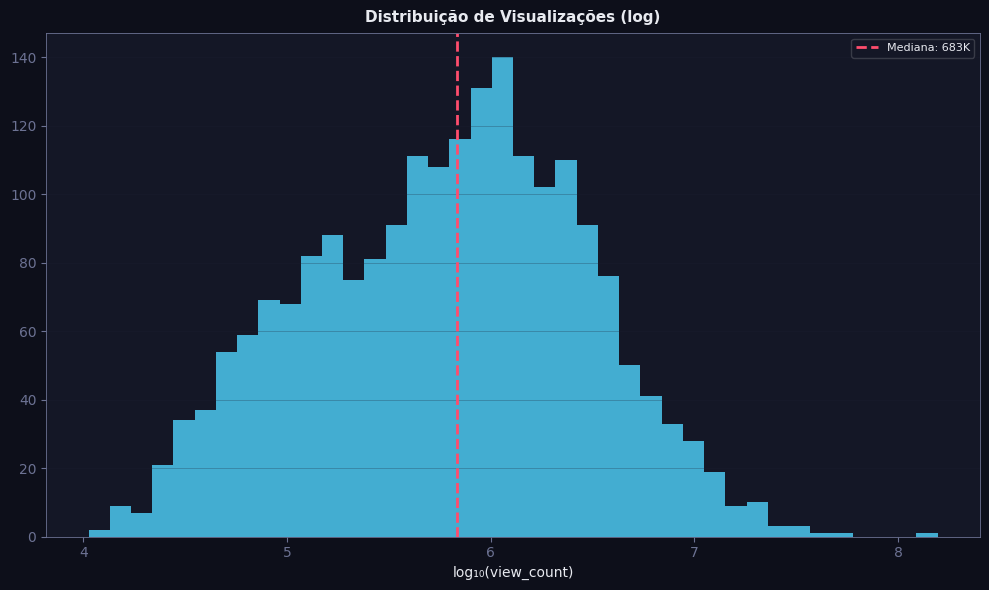

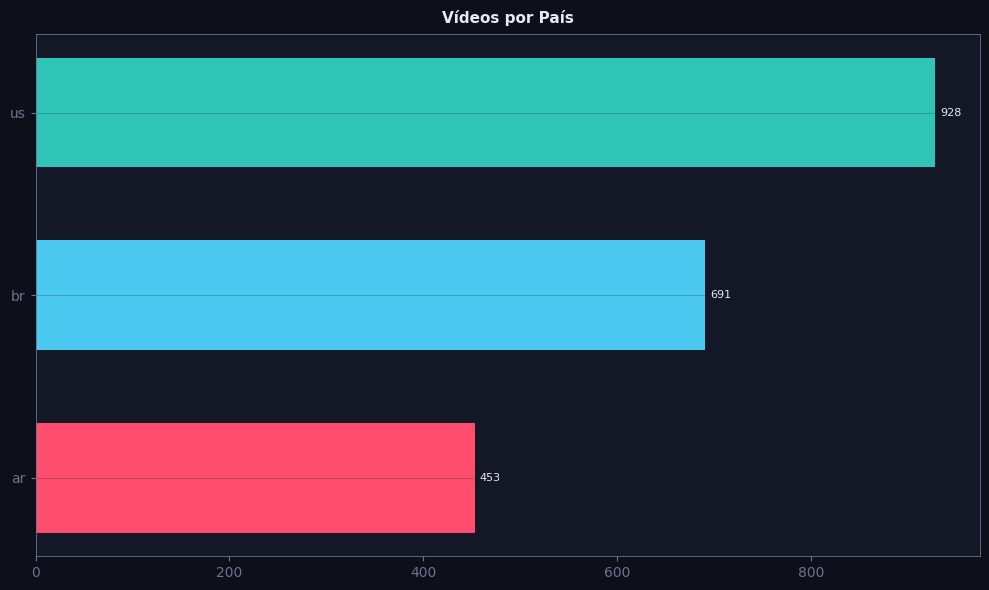

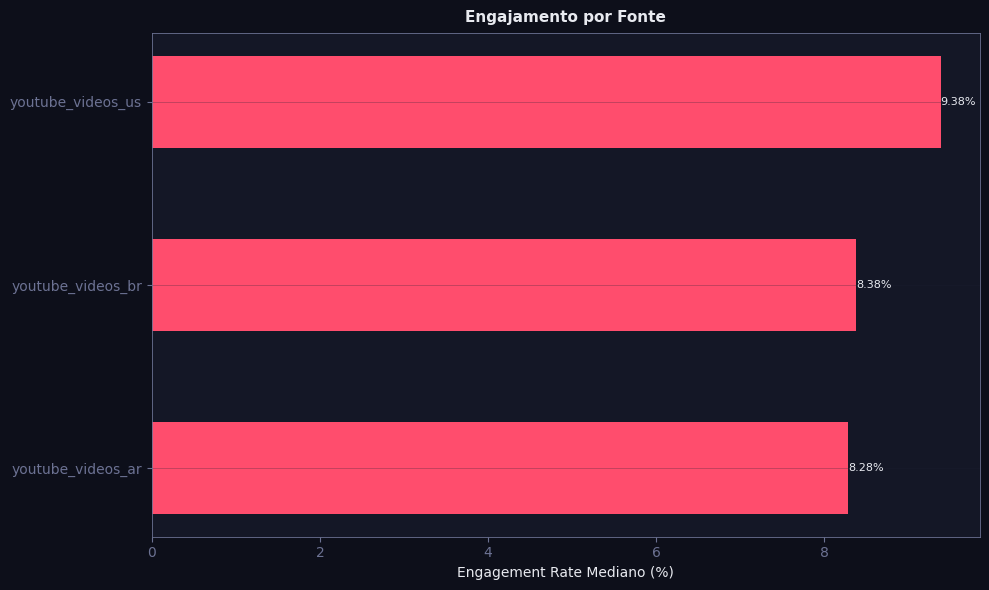

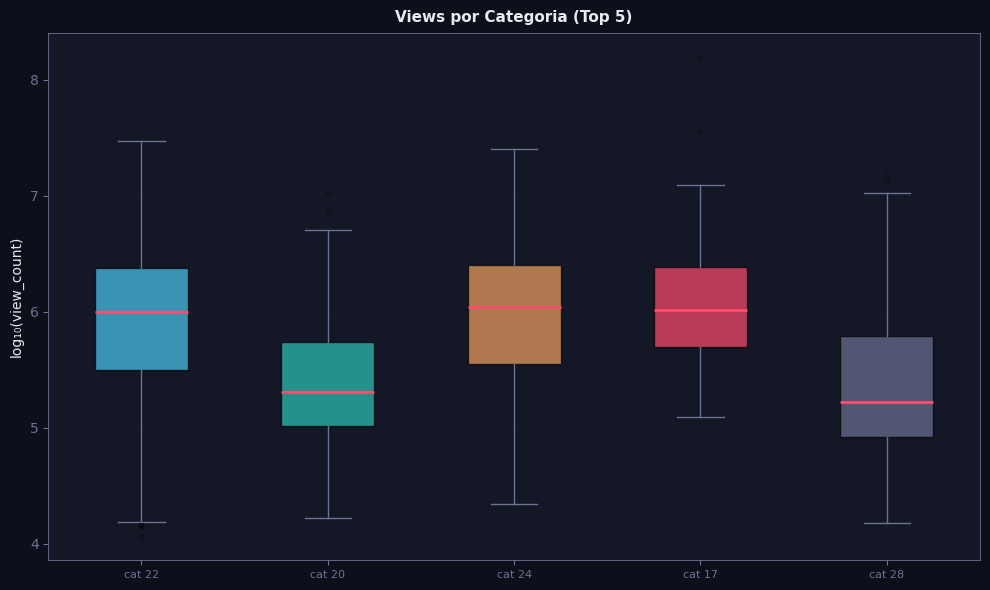

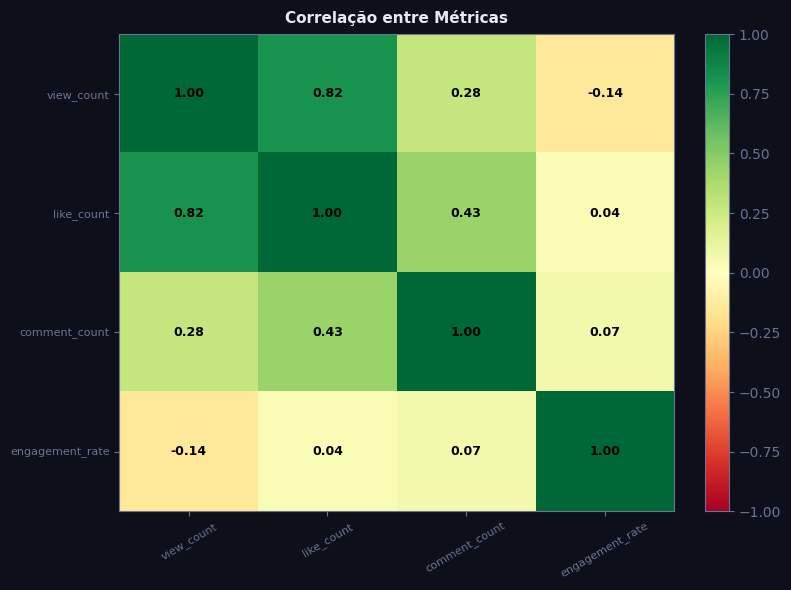

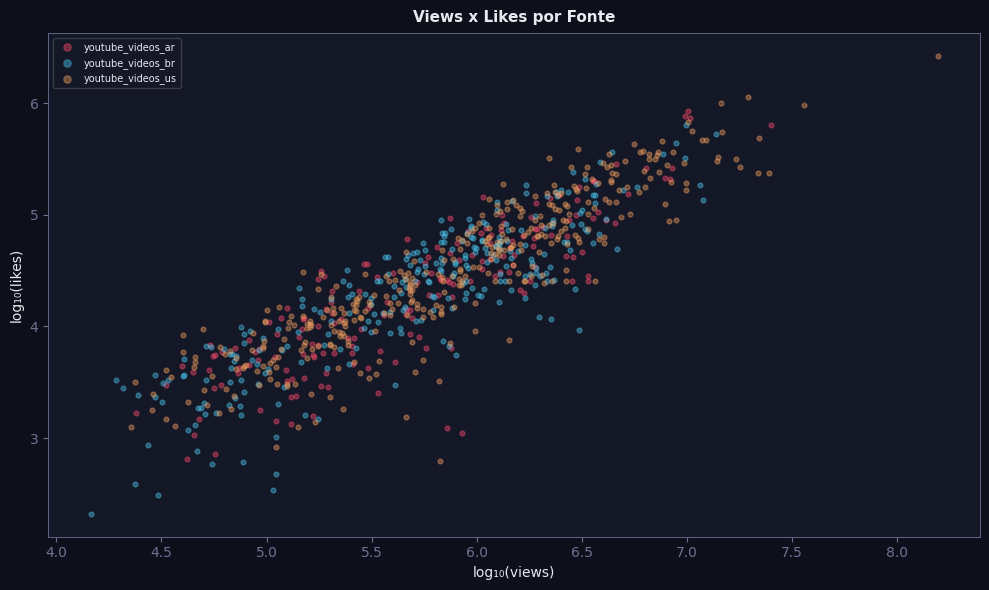

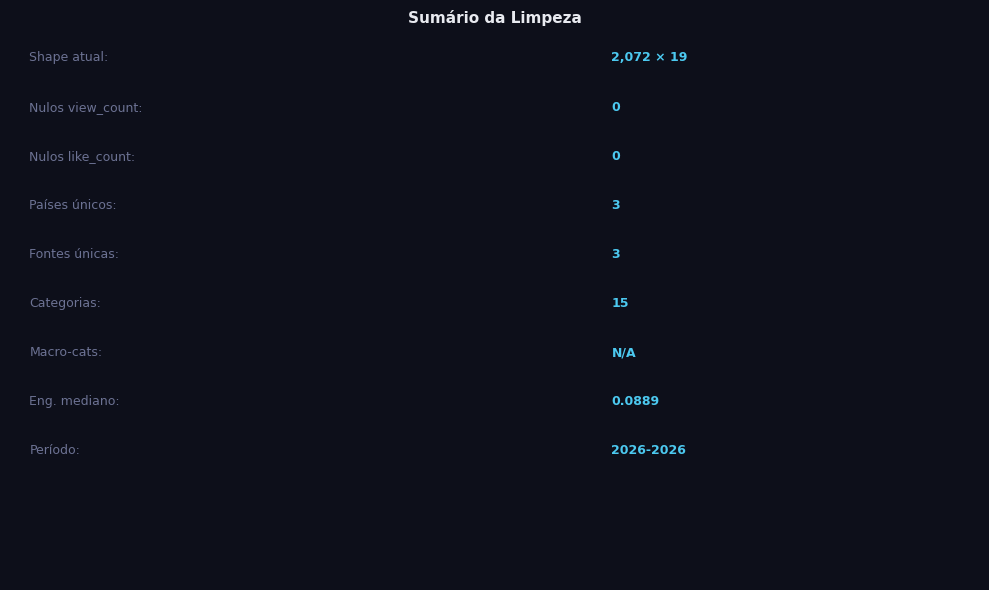

In [ ]:
display(figures[1])
display(figures[2])
display(figures[4])
display(figures[6])
display(figures[7])
display(figures[8])